In [1]:
import os
import glob
import numpy as np
import torch
import torch.optim as optim
from torch.utils.data import DataLoader
import mdtraj as md
import matplotlib.pyplot as plt
from nflows import flows, transforms, distributions
from tqdm import tqdm

from src.diffeomorphisms.sequence.nflow import NFlowSequenceDiffeomorphism
from src.dimension_reduction.principal_geodesic_analysis.sequence.l2_tangent_space_pca import l2TangentSpacePCASequenceSolver
from src.manifolds.euclidean.sequence.pullback.standard import StandardPullbackSequenceEuclidean
from src.manifolds.euclidean.sequence.standard import StandardSequenceEuclidean
from src.manifolds.isometrized_euclidean.sequence import l2IsometrizedSequenceEuclidean
from src.transforms.multi_layer_parity_conv1d.tanh import MultiLayerTanhParityConv1DTransform
from src.transforms.normalization.actnorm import ActNorm
from src.transforms.parity_conv1d import ParityConv1DTransform

device = "cuda" if torch.cuda.is_available() else "cpu"

# Set random seed for reproducibility
torch.manual_seed(31)

# Experiment settings
results_folder = os.path.join("results",f"4ake","additive-tanh-isotropic-nflow-pullback")
train_model = True

plt.rcParams['font.size'] = 20  # Change this value to your desired font size

### Learning Geometry ###

dcdplugin) detected standard 32-bit DCD file of native endianness
dcdplugin) CHARMM format DCD file (also NAMD 2.1 and later)
Loaded trajectory with shape: torch.Size([102, 3, 214])
Augmented dataset shape: torch.Size([5100, 3, 214])


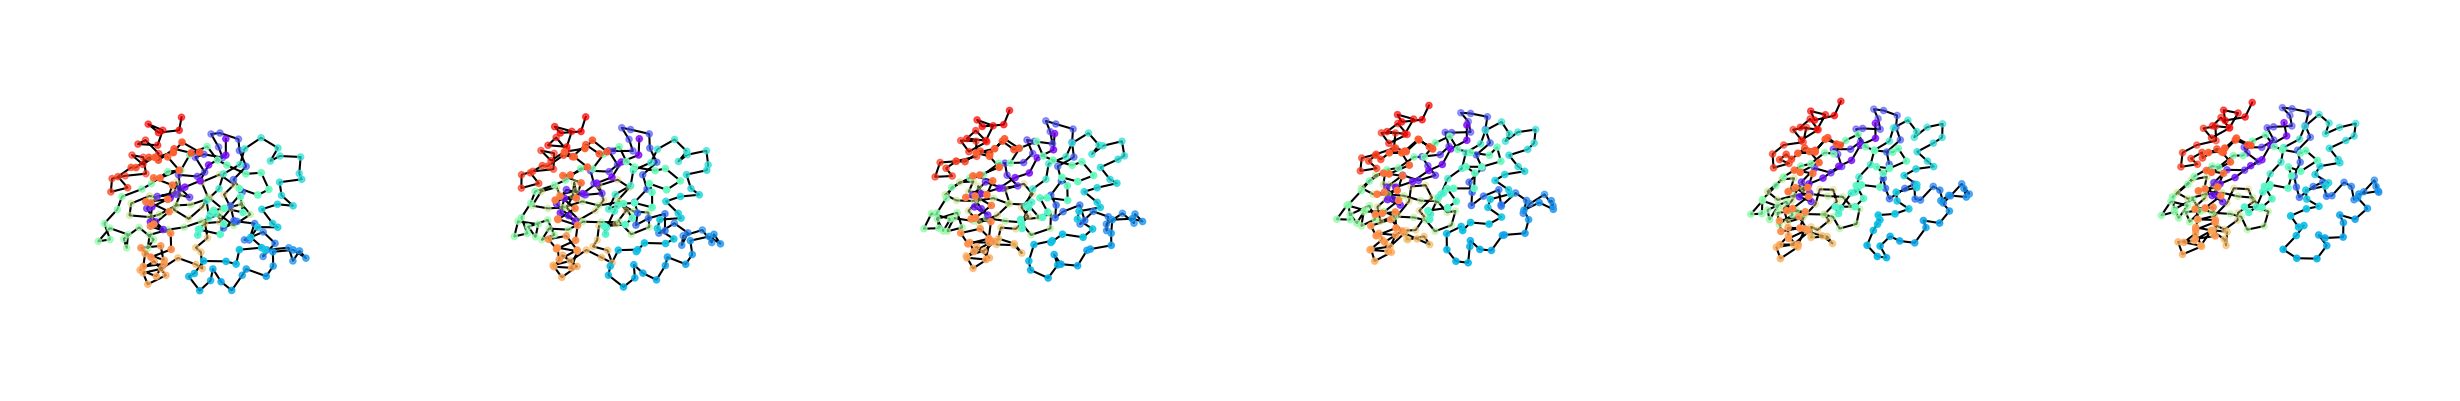

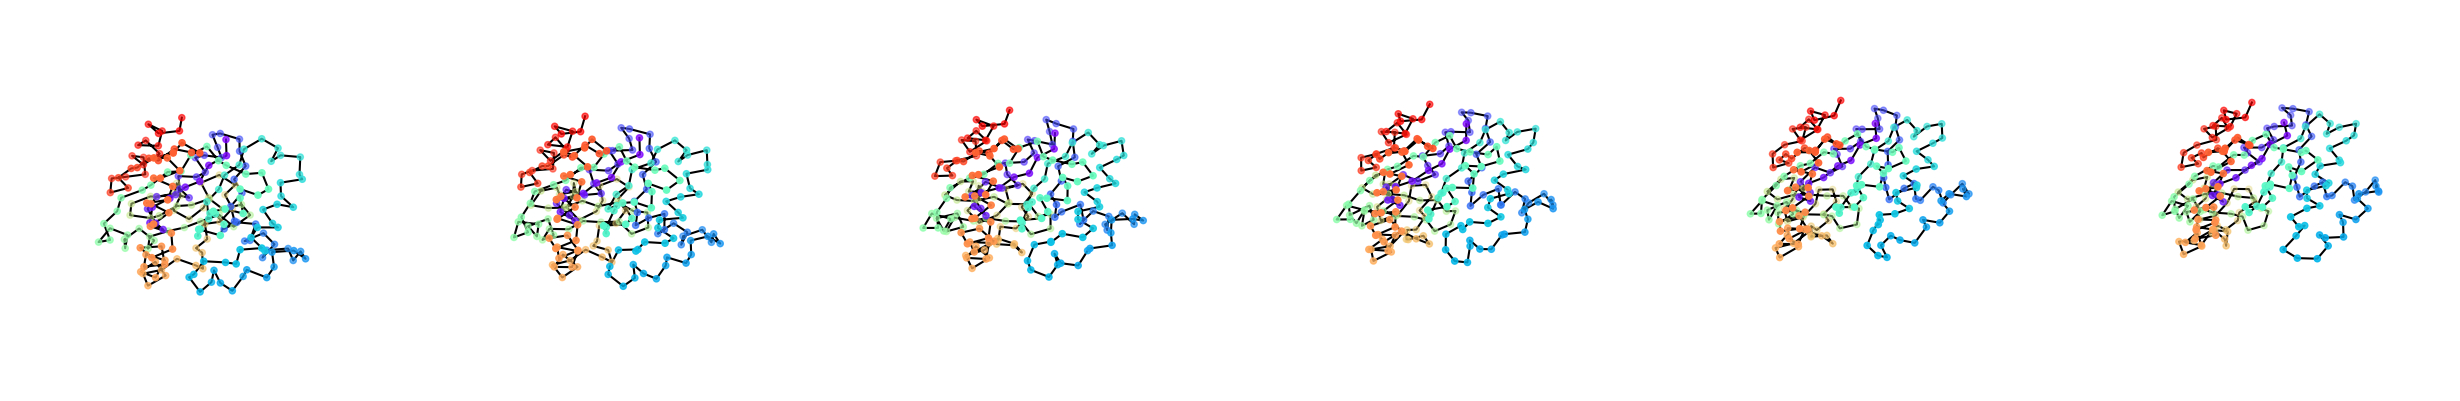

In [2]:
trajectory_path = os.path.join("data", "4ake", "dims0001_fit-core.dcd")
topology_path = os.path.join("data", "4ake", "adk4ake.psf")

trajectory = md.load(trajectory_path, top = topology_path)

# get Calpha positions
indices = []

for m in trajectory.topology.atoms_by_name('CA'):
    indices.append(m.index)

ca_pos = torch.tensor(trajectory.xyz[:,indices,:]).permute(0, 2, 1).float()  # shape: (num_frames, 3, num_atoms)

print(f"Loaded trajectory with shape: {ca_pos.shape}")
protein_length = ca_pos.shape[2]
traj_length = ca_pos.shape[0]

# add noise to the data for data augmentation to increase the number of samples tenfold
noise_std = 0.01  # Standard deviation of the noise
for i in range(50):  # Repeat 10 times
    noise = torch.randn_like(ca_pos) * noise_std
    data_train = torch.cat((data_train, ca_pos + noise), dim=0) if 'data_train' in locals() else ca_pos + noise
data_val = ca_pos  # Use the original data for validation

print(f"Augmented dataset shape: {data_train.shape}")

# Create the DataLoaders
batch_size = 128
train_loader = DataLoader(data_train, batch_size=batch_size, shuffle=False)
val_loader = DataLoader(data_val, batch_size=batch_size, shuffle=False)

# Get a batch of examples from the training set
train_examples = next(iter(train_loader))
train_conf = train_examples

# Plot 6 conformations from the training set
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = data_val[g_ind, 0, :]
    y = data_val[g_ind, 1, :]
    z = data_val[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

# Plot 6 conformations from the training set
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = train_conf[g_ind, 0, :]
    y = train_conf[g_ind, 1, :]
    z = train_conf[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [3]:
# Define the normalizing flow model
def create_flow_model(length, kernel_size, latent_channels, order, n_flows, actnorm=True):
    in_channels = 3
    base_dist = distributions.StandardNormal(shape=[in_channels, length])   
    transforms_list = []
    for i in range(n_flows):
        if actnorm:
            transforms_list.append(ActNorm(features=in_channels))
        transforms_list.append(ParityConv1DTransform(in_channels, length, kernel_size=kernel_size, parity=i))
        transforms_list.append(ParityConv1DTransform(in_channels, length, kernel_size=kernel_size, parity=i+1))
        transforms_list.append(MultiLayerTanhParityConv1DTransform(in_channels, length, kernel_size, latent_channels, order=order, parity=i))
    if actnorm:
            transforms_list.append(ActNorm(features=in_channels))
    transforms_list.append(ParityConv1DTransform(in_channels, length, kernel_size, parity=n_flows))
    transforms_list.append(ParityConv1DTransform(in_channels, length, kernel_size, parity=n_flows+1))
    flow_transforms = transforms.CompositeTransform(transforms_list)
    return flows.Flow(transform=flow_transforms, distribution=base_dist)

In [4]:
# Initialize the model
L = 16
K = 15
order = 2
n_flows = 8
model = create_flow_model(protein_length, K, L, order, n_flows).to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

In [5]:
# Generate samples
@torch.no_grad()
def generate_samples(model, n_samples):
    samples = model.sample(n_samples).cpu()
    return samples

In [6]:
# Training loop
def train(phi, train_loader, optimizer, n_epochs, save_dir='results', start_epoch=0):
    best_loss = float('inf')
    os.makedirs(save_dir, exist_ok=True)

    for epoch in range(start_epoch, n_epochs):
        epoch_loss = 0
        for x in tqdm(train_loader, desc=f"Epoch {epoch+1}/{n_epochs}"):
            optimizer.zero_grad()

            # Compute loss
            loss = -phi.nflow.log_prob(x.to(device)).mean()
            
            # Backward pass and optimization
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
        
        # Calculate average loss for the epoch
        avg_epoch_loss = epoch_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{n_epochs}, Average Loss: {avg_epoch_loss:.4f}")

        # Save checkpoint
        checkpoint = {
            'epoch': epoch,
            'model_state_dict': phi.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': loss,
            'best_loss': best_loss,
        }
        
        if (epoch + 1) % 25 == 0:
            torch.save(checkpoint, os.path.join(save_dir, f'epoch_{epoch+1}_model.pth'))

        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            torch.save(checkpoint, os.path.join(save_dir, 'best_model.pth'))

    print("Training completed. Best model saved with loss:", best_loss)

In [7]:
# Train the model
n_epochs = 25

# Construct diffeomorphism
phi = NFlowSequenceDiffeomorphism(3, protein_length, model)
checkpoint_dir = os.path.join(results_folder, f"checkpoints_latent_dim={L}_kernel_size={K}_order={order}_n_flows={n_flows}")

# Train or load model
if train_model:
    start_epoch = 0
    best_loss = float('inf')

    # Check if there's a checkpoint to resume from
    latest_checkpoint = max(glob.glob(os.path.join(checkpoint_dir, 'epoch_*_model.pth')), default=None, key=os.path.getctime)
    
    if latest_checkpoint:
        print(f"Resuming training from {latest_checkpoint}")
        checkpoint = torch.load(latest_checkpoint)
        phi.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_loss = checkpoint['best_loss']

    train(phi, train_loader, optimizer, n_epochs, save_dir=checkpoint_dir, start_epoch=start_epoch)
else:
    # best_model_path = os.path.join(checkpoint_dir, 'epoch_200_model.pth')
    best_model_path = os.path.join(checkpoint_dir, 'best_model.pth')
    checkpoint = torch.load(best_model_path,map_location=device)
    phi.load_state_dict(checkpoint['model_state_dict'])

# Set the model to evaluation mode
phi.eval()

Epoch 1/50: 100%|██████████| 40/40 [01:18<00:00,  1.96s/it]


Epoch 1/50, Average Loss: 972.3009


Epoch 2/50: 100%|██████████| 40/40 [01:18<00:00,  1.96s/it]


Epoch 2/50, Average Loss: 662.0828


Epoch 3/50: 100%|██████████| 40/40 [01:18<00:00,  1.96s/it]


...

Epoch 33/50, Average Loss: -898.3630


Epoch 34/50: 100%|██████████| 40/40 [11:00<00:00, 16.52s/it]   


Epoch 34/50, Average Loss: -926.2283


Epoch 35/50:  75%|███████▌  | 30/40 [14:16<04:45, 28.56s/it]  


KeyboardInterrupt: 

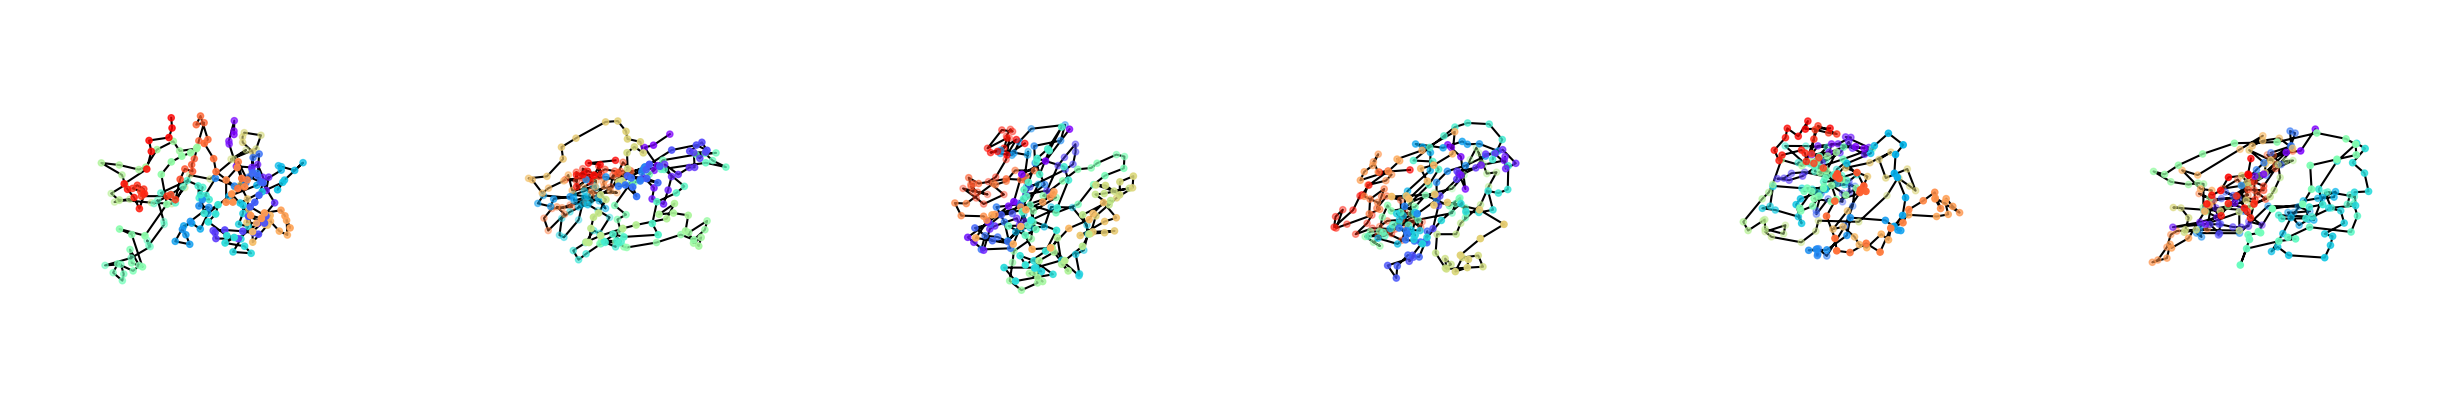

In [8]:
# Visualize generated samples
samples = generate_samples(phi.nflow, 100).reshape(-1, 3, protein_length)

# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    x = samples[i, 0, :]
    y = samples[i, 1, :]
    z = samples[i, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

In [9]:
# special points
num_points = 10

x0 = data_val[0].to(device)
x1 = data_val[-1].to(device)

### Naive Riemannian data analysis ###

In [10]:
# Construct pullback manifold
manifold = StandardPullbackSequenceEuclidean(phi)

In [11]:
# Compute geodesics
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesic
geodesic = manifold.geodesic(x0[None,None], x1[None,None], t).detach().cpu()[0,0,0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


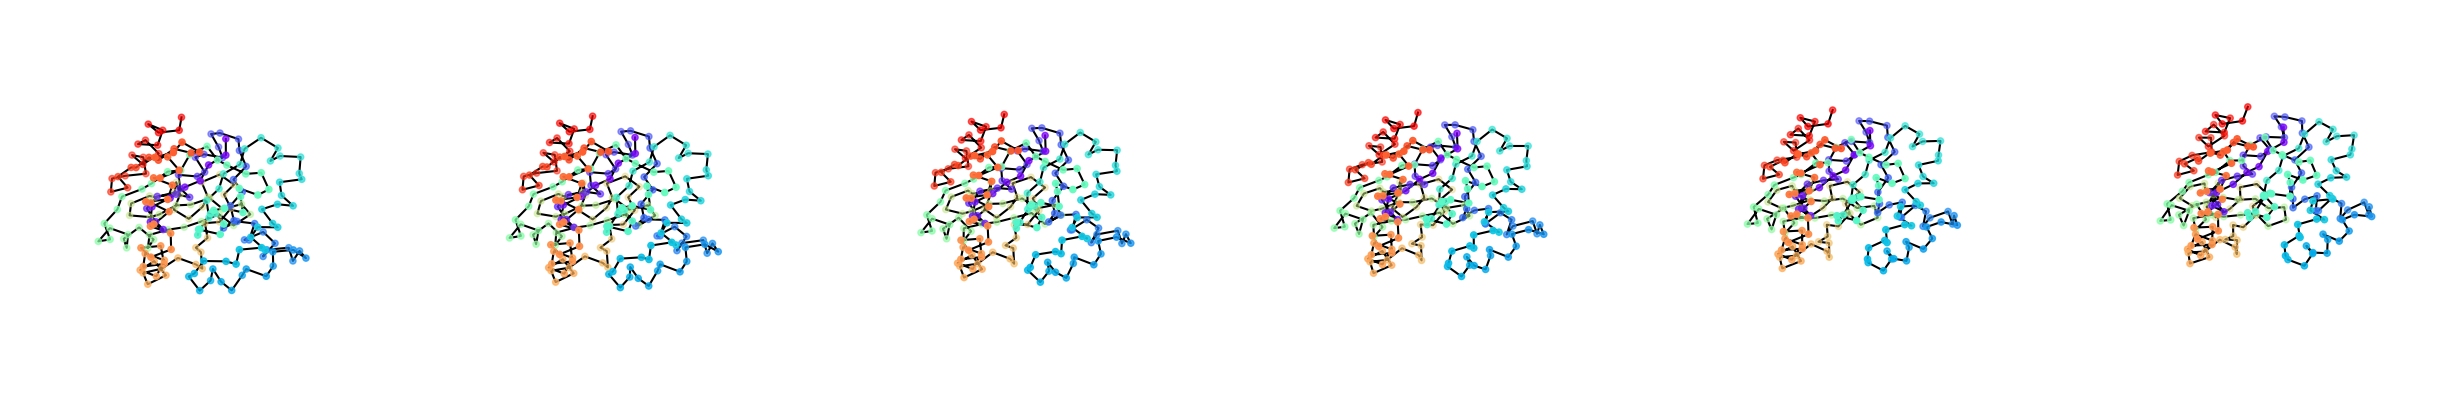

In [12]:
# Plot each image in the grid
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    x = geodesic[i, 0, :]
    y = geodesic[i, 1, :]
    z = geodesic[i, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"geodesic.eps"))
plt.show()

In [13]:
# Compute barycentre
bary = manifold.barycentre(data_val.to(device)).detach().cpu()

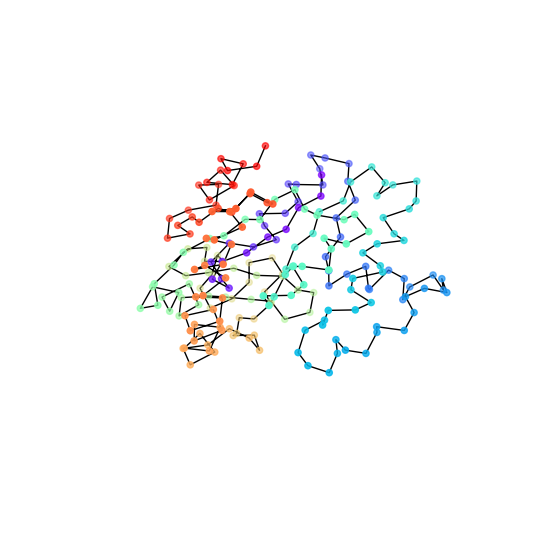

In [14]:
# Plot barycentres
fig = plt.figure(figsize=(6, 6))
ax = fig.add_subplot(111, projection='3d')

x = bary[0]
y = bary[1]
z = bary[2]

ax.plot3D(x, y, z, color='black', linewidth=1)
ax.scatter(x, y, z, c=np.linspace(0, 1, len(x)), cmap='rainbow', s=20)

ax.set_axis_off()
plt.tight_layout()
plt.show()

In [15]:
# Construct curvature corrected l2-pga solver
l2_pga_solver = l2TangentSpacePCASequenceSolver(data_val.to(device), manifold, bary.to(device))

In [16]:
# Compute low rank approximations
Xi_bary, exp_bary_Xi, _ = l2_pga_solver.solve(20)

Computing rank 20 approximation on tangent space
Computing rank 20 approximation on euclidean space
Computing rank 20 errors for data point 1/102
Computing rank 20 errors for data point 2/102
Computing rank 20 errors for data point 3/102
Computing rank 20 errors for data point 4/102
Computing rank 20 errors for data point 5/102
Computing rank 20 errors for data point 6/102
Computing rank 20 errors for data point 7/102
Computing rank 20 errors for data point 8/102
Computing rank 20 errors for data point 9/102
Computing rank 20 errors for data point 10/102
Computing rank 20 errors for data point 11/102
Computing rank 20 errors for data point 12/102
Computing rank 20 errors for data point 13/102
Computing rank 20 errors for data point 14/102
Computing rank 20 errors for data point 15/102
Computing rank 20 errors for data point 16/102
Computing rank 20 errors for data point 17/102
Computing rank 20 errors for data point 18/102
Computing rank 20 errors for data point 19/102
Computing rank 2

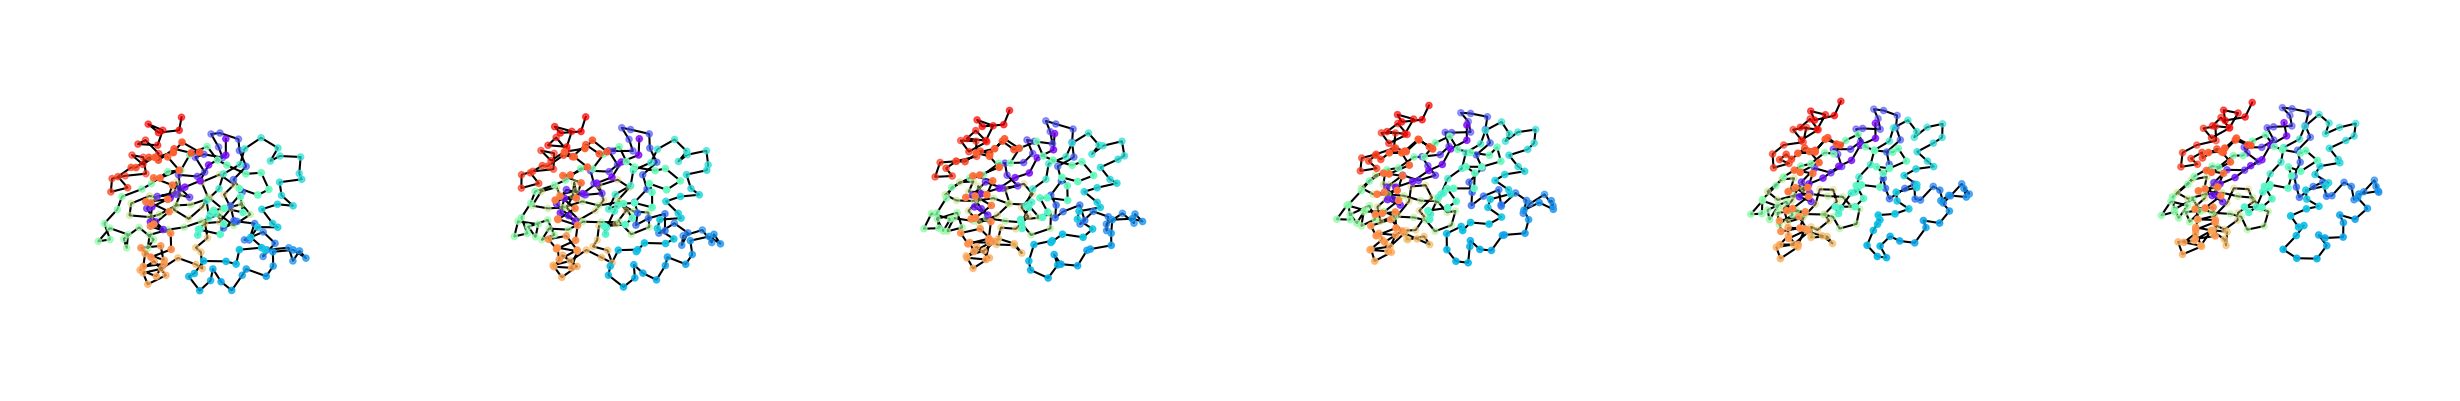

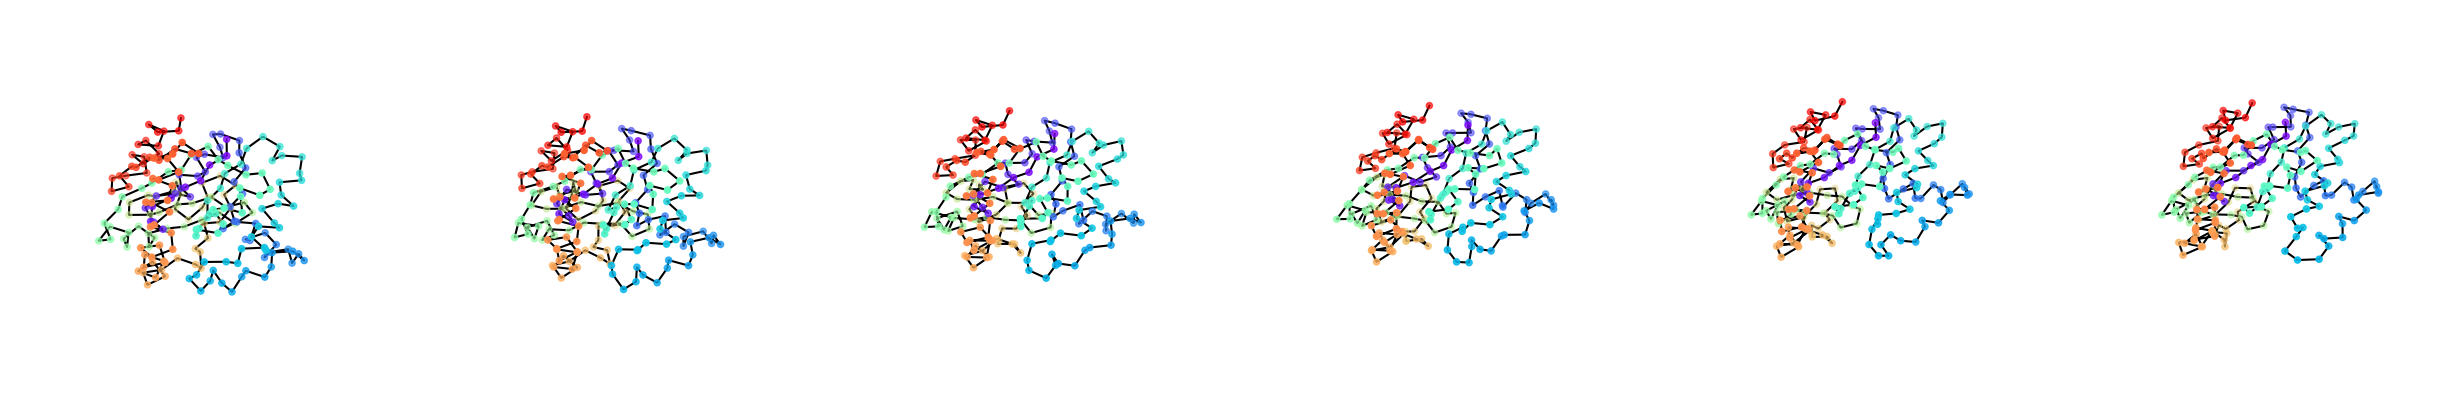

In [17]:
# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = data_val[g_ind, 0, :]
    y = data_val[g_ind, 1, :]
    z = data_val[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = exp_bary_Xi[g_ind, 0, :]
    y = exp_bary_Xi[g_ind, 1, :]
    z = exp_bary_Xi[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

### Isometrized Riemannian data analysis ###

In [18]:
# Construct isometrized pullback manifold
num_intervals = 20  # You can adjust this value as needed
iso_manifold = l2IsometrizedSequenceEuclidean(manifold, num_intervals=num_intervals)

In [19]:
# Compute geodesics
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesic
iso_geodesic = iso_manifold.geodesic(x0[None,None], x1[None,None], t).detach().cpu()[0,0,0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


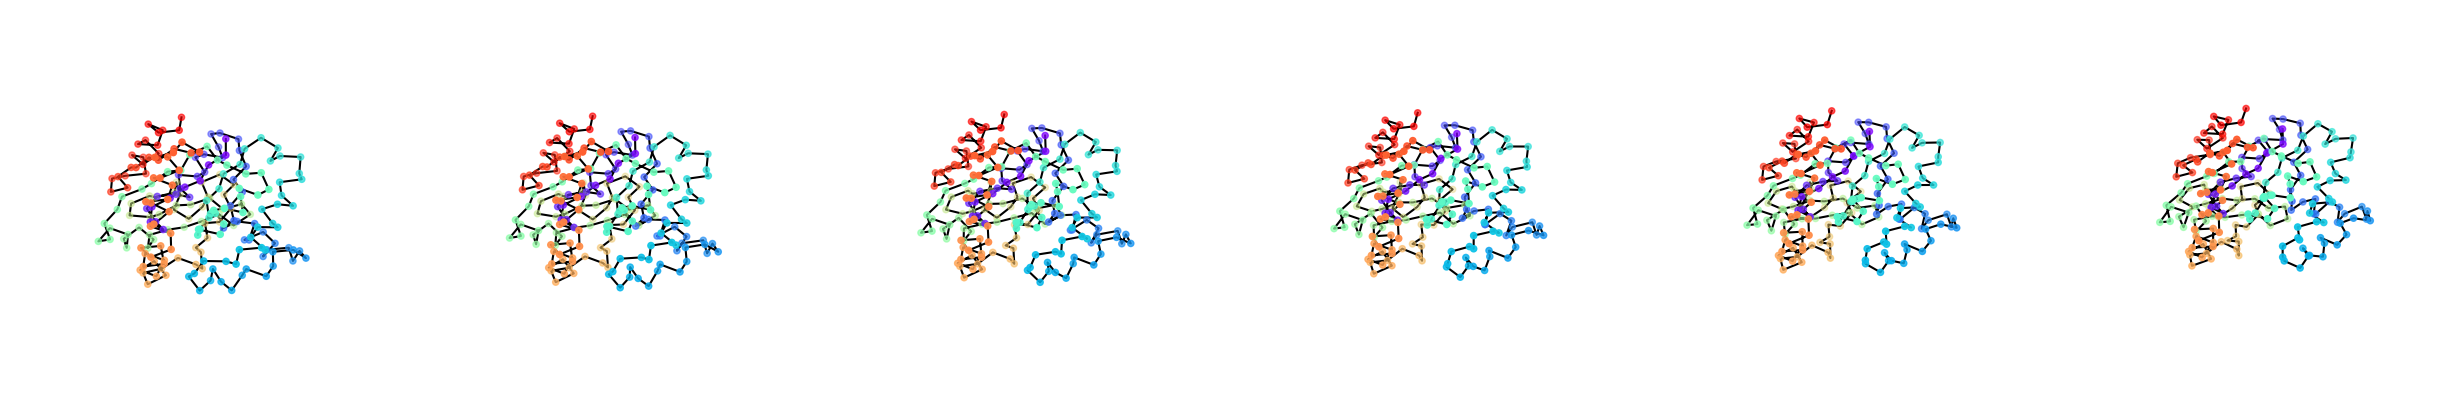

In [20]:
# Plot each image in the grid
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    x = iso_geodesic[i, 0, :]
    y = iso_geodesic[i, 1, :]
    z = iso_geodesic[i, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"iso-geodesic.eps"))
plt.show()

In [21]:
# Construct curvature corrected l2-pga solver
iso_l2_pga_solver = l2TangentSpacePCASequenceSolver(data_val.to(device), iso_manifold, bary.to(device))

In [22]:
# Compute low rank approximations
iso_Xi_bary, iso_exp_bary_Xi, _ = iso_l2_pga_solver.solve(20)

Computing rank 20 approximation on tangent space
Computing rank 20 approximation on euclidean space
Computing rank 20 errors for data point 1/102
Computing rank 20 errors for data point 2/102
Computing rank 20 errors for data point 3/102
Computing rank 20 errors for data point 4/102
Computing rank 20 errors for data point 5/102
Computing rank 20 errors for data point 6/102
Computing rank 20 errors for data point 7/102
Computing rank 20 errors for data point 8/102
Computing rank 20 errors for data point 9/102
Computing rank 20 errors for data point 10/102
Computing rank 20 errors for data point 11/102
Computing rank 20 errors for data point 12/102
Computing rank 20 errors for data point 13/102
Computing rank 20 errors for data point 14/102
Computing rank 20 errors for data point 15/102
Computing rank 20 errors for data point 16/102
Computing rank 20 errors for data point 17/102
Computing rank 20 errors for data point 18/102
Computing rank 20 errors for data point 19/102
Computing rank 2

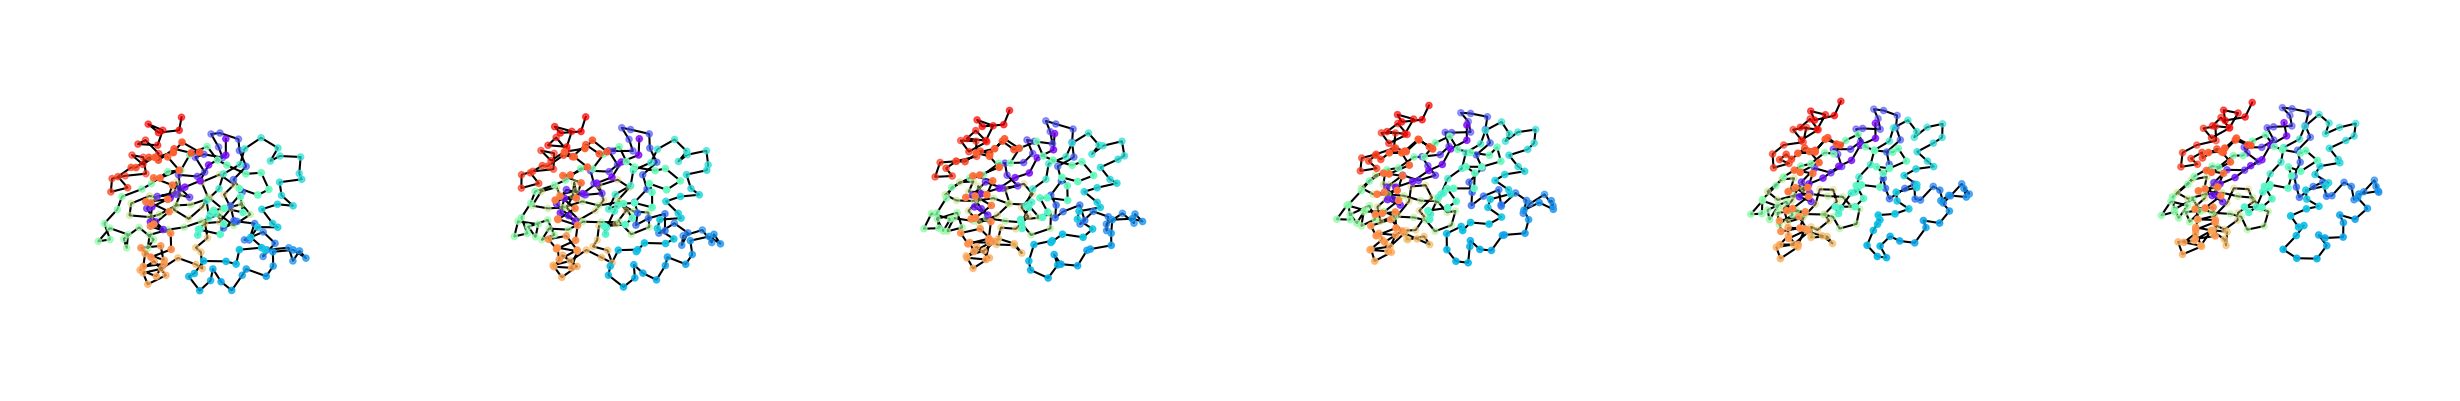

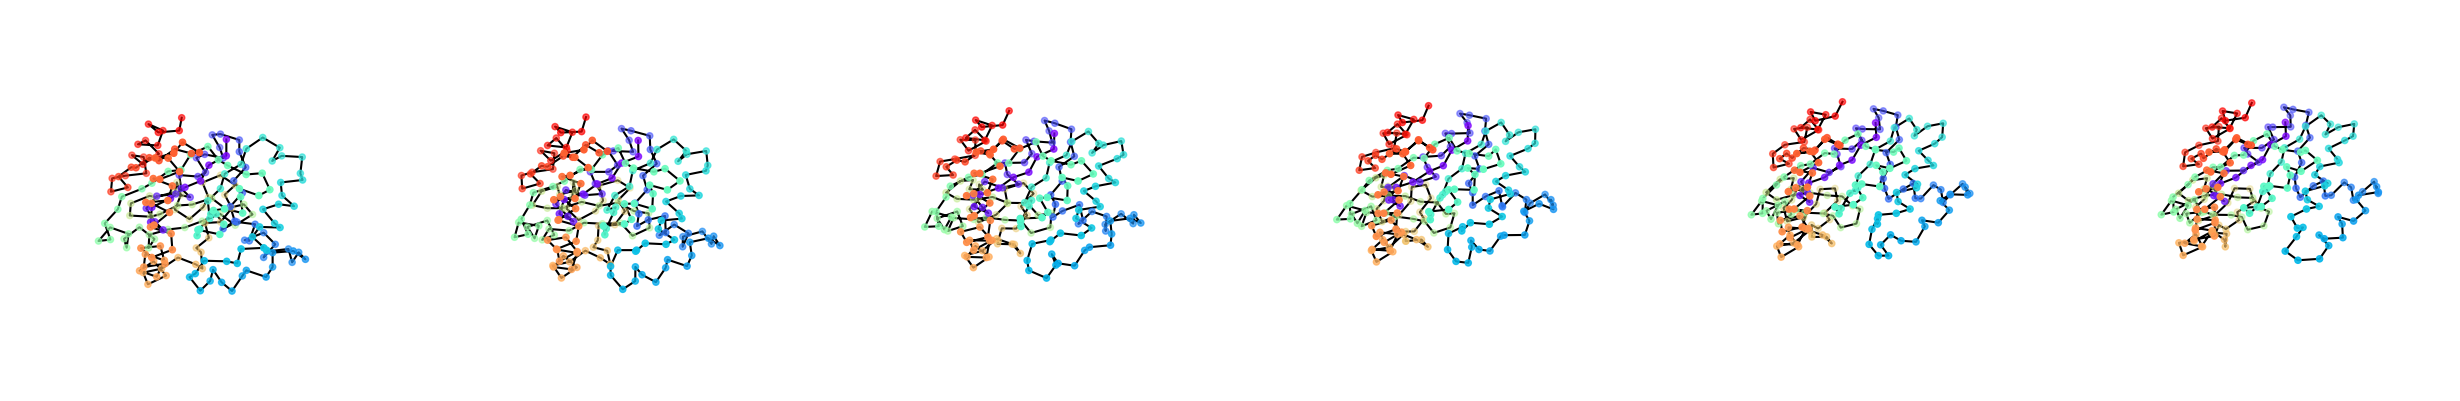

In [23]:
# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = data_val[g_ind, 0, :]
    y = data_val[g_ind, 1, :]
    z = data_val[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = iso_exp_bary_Xi[g_ind, 0, :]
    y = iso_exp_bary_Xi[g_ind, 1, :]
    z = iso_exp_bary_Xi[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

### l2 data analysis ###

In [24]:
# Construct isometrized pullback manifold
l2_manifold = StandardSequenceEuclidean(3, protein_length)

In [25]:
# Compute geodesics
t = torch.linspace(0., 1., num_points).to(device)

# Generate geodesic
l2_geodesic = l2_manifold.geodesic(x0[None,None], x1[None,None], t).detach().cpu()[0,0,0]

The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


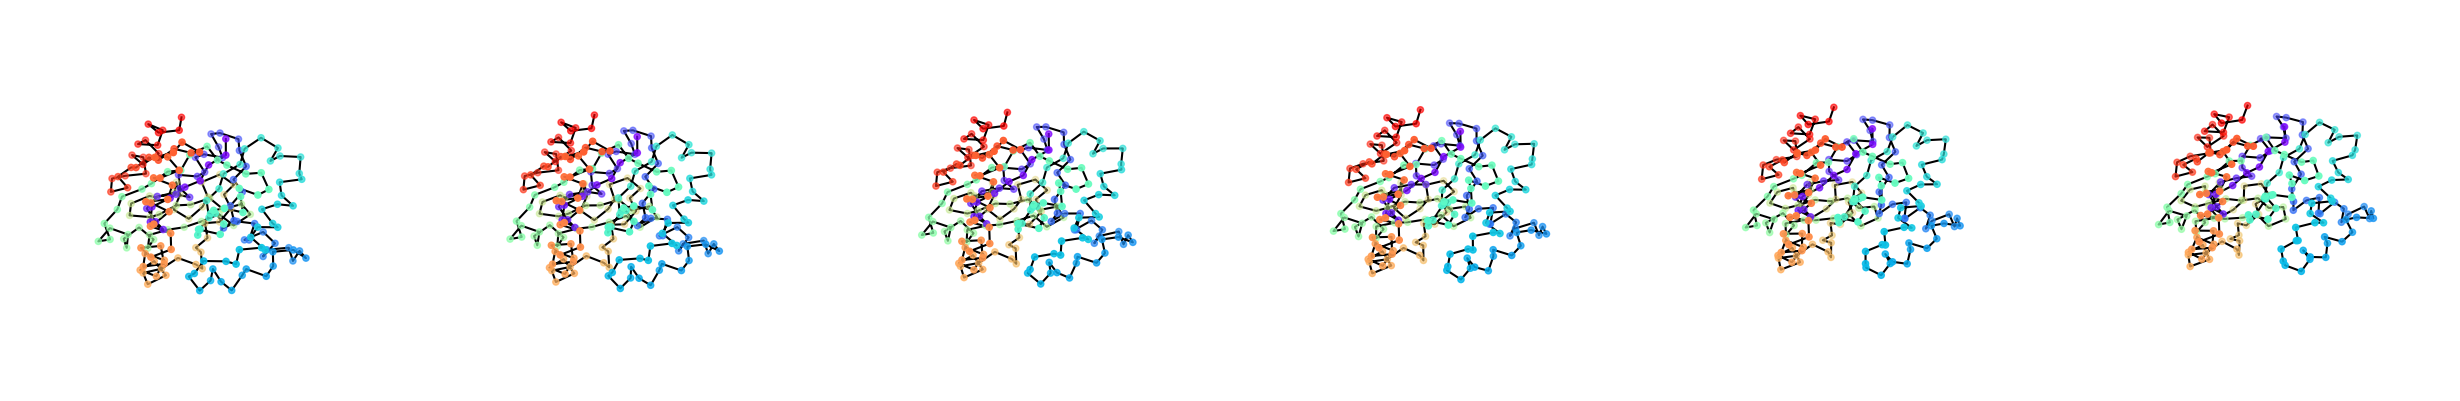

In [26]:
# Plot each image in the grid
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    x = l2_geodesic[i, 0, :]
    y = l2_geodesic[i, 1, :]
    z = l2_geodesic[i, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.savefig(os.path.join(results_folder,f"l2-geodesic.eps"))
plt.show()

In [27]:
# Construct curvature corrected l2-pga solver
l2_pca_solver = l2TangentSpacePCASequenceSolver(data_val.to(device), l2_manifold, bary.to(device))

In [28]:
# Compute low rank approximations
l2_Xi_bary, l2_exp_bary_Xi, _ = l2_pca_solver.solve(20)

Computing rank 20 approximation on tangent space
Computing rank 20 approximation on euclidean space
Computing rank 20 errors for data point 1/102
Computing rank 20 errors for data point 2/102
Computing rank 20 errors for data point 3/102
Computing rank 20 errors for data point 4/102
Computing rank 20 errors for data point 5/102
Computing rank 20 errors for data point 6/102
Computing rank 20 errors for data point 7/102
Computing rank 20 errors for data point 8/102
Computing rank 20 errors for data point 9/102
Computing rank 20 errors for data point 10/102
Computing rank 20 errors for data point 11/102
Computing rank 20 errors for data point 12/102
Computing rank 20 errors for data point 13/102
Computing rank 20 errors for data point 14/102
Computing rank 20 errors for data point 15/102
Computing rank 20 errors for data point 16/102
Computing rank 20 errors for data point 17/102
Computing rank 20 errors for data point 18/102
Computing rank 20 errors for data point 19/102
Computing rank 2

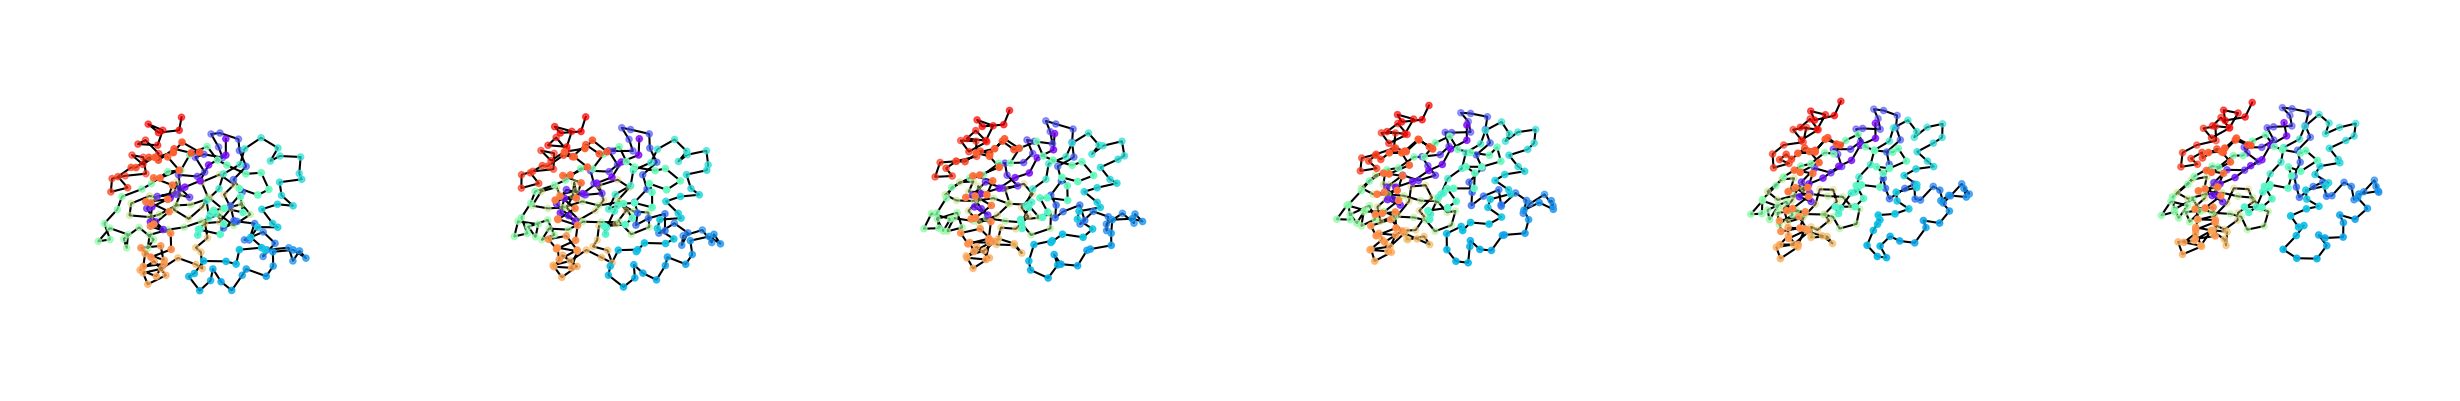

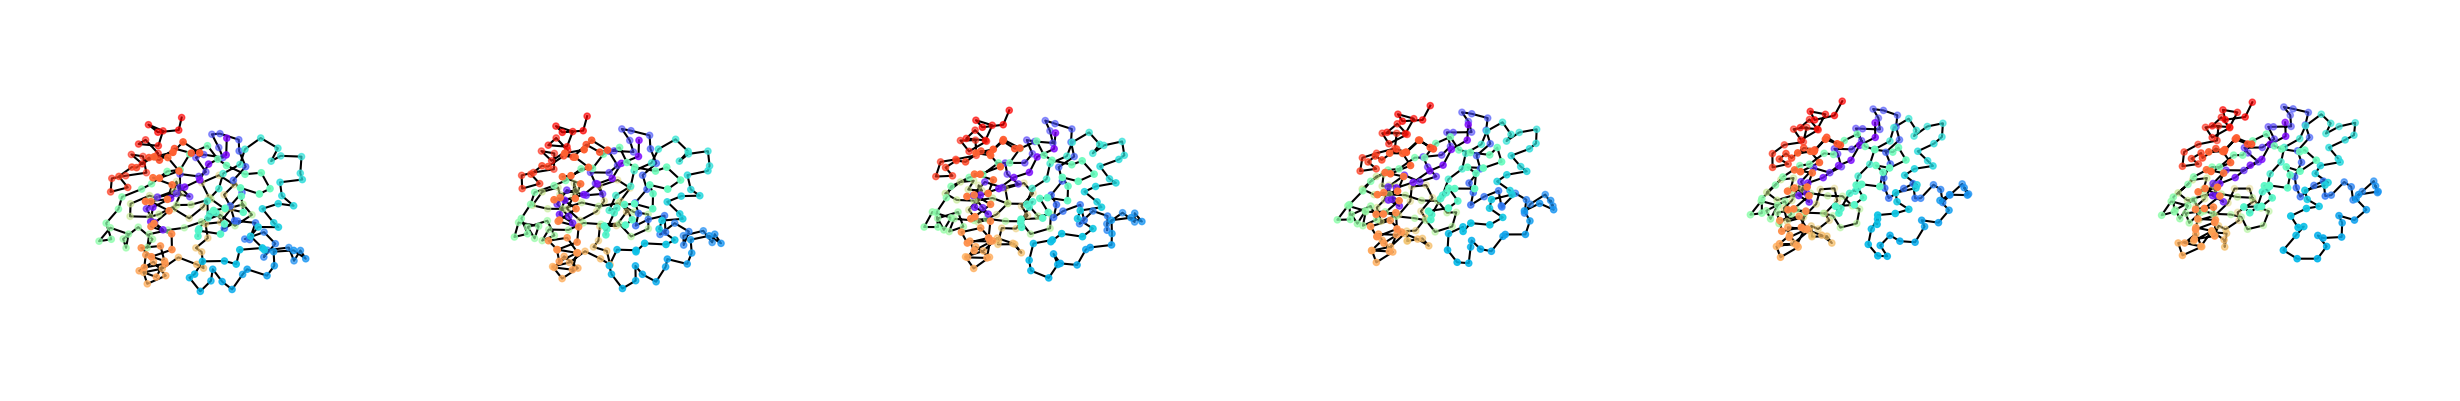

In [29]:
# Plot the first 6 images
fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = data_val[g_ind, 0, :]
    y = data_val[g_ind, 1, :]
    z = data_val[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 6, figsize=(25, 25), subplot_kw={'projection': '3d'})

for i, ax in enumerate(axes):
    g_ind = (i * 102) // 6
    x = l2_exp_bary_Xi[g_ind, 0, :]
    y = l2_exp_bary_Xi[g_ind, 1, :]
    z = l2_exp_bary_Xi[g_ind, 2, :]

    ax.plot3D(x, y, z, color='black')
    ax.scatter(x, y, z, c=np.linspace(0, 1, protein_length), cmap='rainbow', s=20)

    ax.set_axis_off()

plt.tight_layout()
plt.show()

### Comparing naive and isometrized ###

In [30]:
# Compute geodesic relative rmse from the barycentre
squared_geo_errors = torch.zeros(data_val.shape[0])
dists = ((data_val - bary)**2).sum([1,2])
for i, x_i in enumerate(data_val):
    geodesic_i = manifold.geodesic(bary.to(device)[None,None], x_i.to(device)[None,None], t).detach().cpu()[0,0,0]
    iso_geodesic_i = iso_manifold.geodesic(bary.to(device)[None,None], x_i.to(device)[None,None], t).detach().cpu()[0,0,0]
    squared_geo_errors[i] = ((geodesic_i - iso_geodesic_i)**2).mean(0).sum()

geo_rel_rmse = (squared_geo_errors.mean() / dists.mean()).sqrt()
print(geo_rel_rmse)

tensor(0.0206)


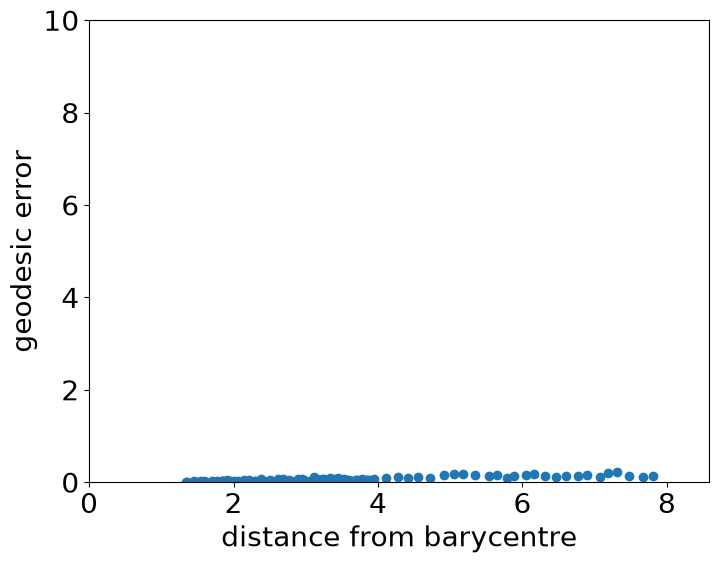

In [31]:
# Make scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dists.sqrt(), squared_geo_errors.sqrt())
plt.xlim([0.,dists.sqrt().max()*1.1])
plt.ylim([0, 10.])
plt.xlabel('distance from barycentre')
plt.ylabel('geodesic error')
plt.savefig(os.path.join(results_folder,f"geo-error-M{num_intervals}.eps"))
plt.show()

In [32]:
# Compute low rank relative rmse from the barycentre
squared_low_rank_errors = ((data_val - exp_bary_Xi.cpu())**2).sum([1,2])
low_rank_rel_rmse = (squared_low_rank_errors.mean() / dists.mean()).sqrt()

squared_low_rank_iso_errors = ((data_val - iso_exp_bary_Xi.cpu())**2).sum([1,2])
iso_low_rank_rel_rmse = (squared_low_rank_iso_errors.mean() / dists.mean()).sqrt()

squared_low_rank_l2_errors = ((data_val - l2_exp_bary_Xi.cpu())**2).sum([1,2])
l2_low_rank_rel_rmse = (squared_low_rank_l2_errors.mean() / dists.mean()).sqrt()

print(low_rank_rel_rmse)
print(iso_low_rank_rel_rmse)
print(l2_low_rank_rel_rmse)

tensor(0.1135)
tensor(0.1119)
tensor(0.0884)


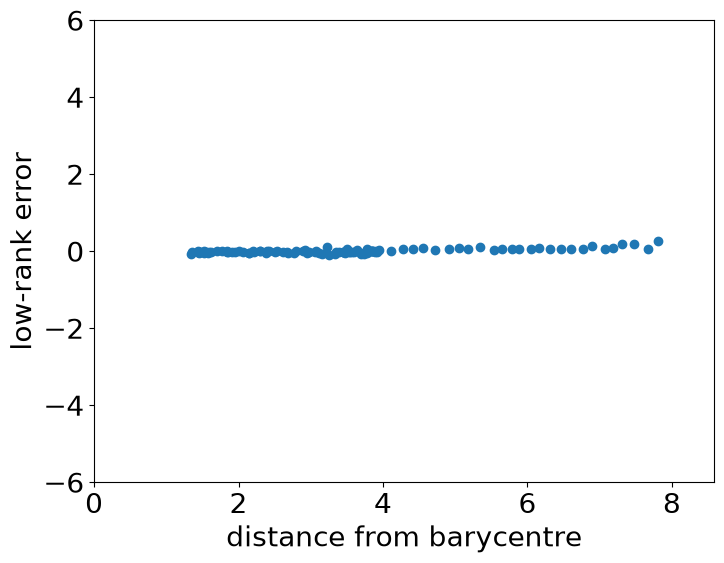

In [33]:
# Make scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(dists.sqrt(), squared_low_rank_errors.sqrt() - squared_low_rank_iso_errors.sqrt())
plt.xlim([0.,dists.sqrt().max()*1.1])
plt.ylim([-6., 6.])
plt.xlabel('distance from barycentre')
plt.ylabel('low-rank error')
plt.savefig(os.path.join(results_folder,f"low-rank-error-M{num_intervals}.eps"))
plt.show()